In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
cd drive/MyDrive/

/content/drive/MyDrive


In [4]:
df = pd.read_csv('Smart-Warehouse-Delay/data/train.csv')
df

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,8.10,0.2586,4.17,0.0856,16.0,9.47,99.0,NaN,4.47,97.13
249996,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,8.63,0.2783,5.61,0.0526,19.6,11.41,NaN,0.0438,NaN,96.73
249997,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,NaN,0.2659,4.94,0.0379,16.5,13.26,95.9,NaN,3.24,98.86
249998,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,9.39,0.1736,4.40,0.0320,20.2,11.04,98.7,0.0519,1.97,98.63


#
### **🌡️ 8. 창고 내부 환경**
* warehouse_temp_avg → 창고 평균 온도
* humidity_pct → 습도
* lighting_level_lux → 조도
* ambient_noise_db → 소음 수준
* floor_vibration_idx → 바닥 진동 지수
* air_quality_idx → 공기질 지수
* co2_level_ppm → 이산화탄소 농도

In [5]:
env_internal = df[["warehouse_temp_avg","humidity_pct","lighting_level_lux",
        "ambient_noise_db","floor_vibration_idx",
        "air_quality_idx","co2_level_ppm"]]
env_internal

,warehouse_temp_avg,humidity_pct,lighting_level_lux,ambient_noise_db,floor_vibration_idx,air_quality_idx,co2_level_ppm
0,NaN,59.1,200.0,75.1,0.7036,12.2,804.0
1,19.52,62.7,217.0,83.3,0.7158,24.8,619.0
2,NaN,67.1,200.0,NaN,0.4420,10.2,834.0
3,18.73,51.7,261.0,79.0,0.5258,3.9,874.0
4,20.51,55.6,221.0,NaN,0.5129,5.8,891.0
...,...,...,...,...,...,...,...
249995,17.46,20.5,383.0,50.0,0.7879,51.4,447.0
249996,15.11,20.0,457.0,57.5,0.7686,NaN,497.0
249997,16.71,30.8,488.0,56.9,0.7862,80.4,400.0
249998,15.00,25.4,348.0,50.0,0.6488,84.7,400.0


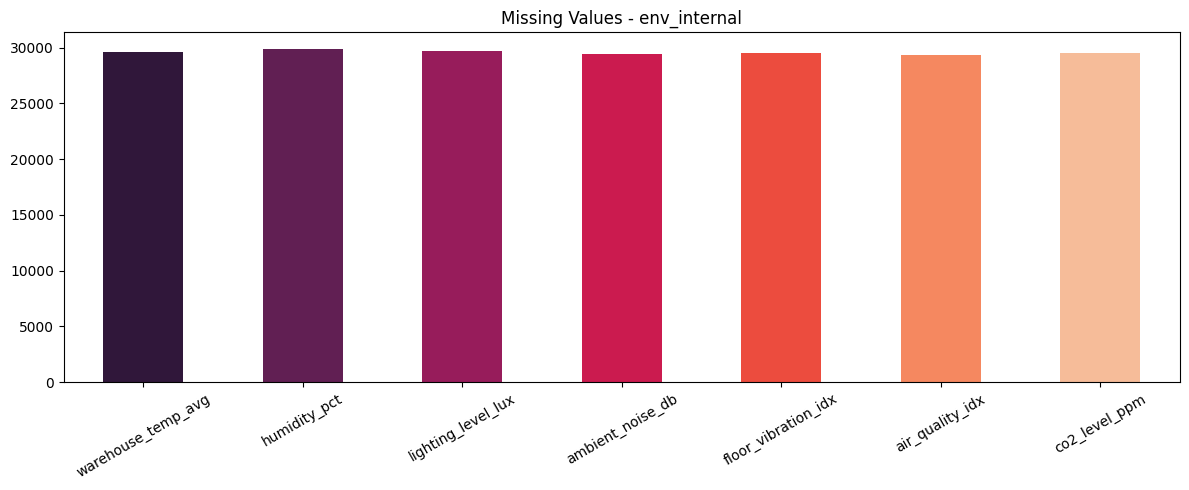

In [6]:
missing = env_internal.isnull().sum()

colors = sns.color_palette("rocket", len(missing))

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color=colors)

plt.title('Missing Values - env_internal')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#
### **상관관계 분석**
* 상관관계가 없는 것으로 판단

In [7]:
corr = env_internal.corr()
corr

,warehouse_temp_avg,humidity_pct,lighting_level_lux,ambient_noise_db,floor_vibration_idx,air_quality_idx,co2_level_ppm
warehouse_temp_avg,1.000000,-0.000065,0.006275,0.004040,0.002326,-0.003290,0.019248
humidity_pct,-0.000065,1.000000,0.017515,0.012524,0.009376,0.013667,-0.008129
lighting_level_lux,0.006275,0.017515,1.000000,0.003338,0.014716,-0.016022,-0.003886
ambient_noise_db,0.004040,0.012524,0.003338,1.000000,0.012210,-0.002494,-0.004180
floor_vibration_idx,0.002326,0.009376,0.014716,0.012210,1.000000,-0.002389,0.010462
air_quality_idx,-0.003290,0.013667,-0.016022,-0.002494,-0.002389,1.000000,-0.000190
co2_level_ppm,0.019248,-0.008129,-0.003886,-0.004180,0.010462,-0.000190,1.000000


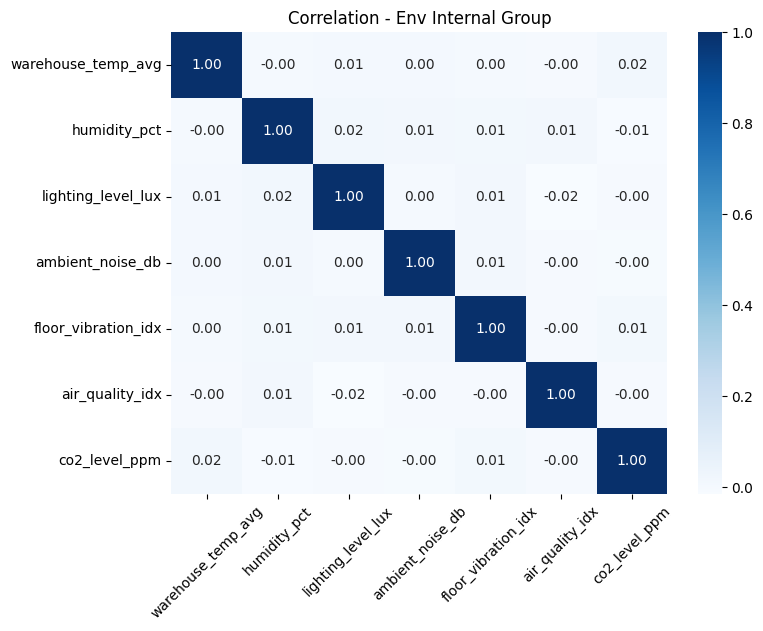

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")

plt.title('Correlation - Env Internal Group')
plt.xticks(rotation=45)
plt.show()